# (샘플) MLP로 MNIST분석
> 작성완료 

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [파이썬, 샘플, 텐서플로우]

# 1. Import 

In [1]:
# import tensorflow as tf
# from tensorflow import keras
# import requests 
# exec(requests.get("http://miruetoto.github.io/source/datahandling.py").text)
# %load_ext rpy2.ipython

In [2]:
import tensorflow as tf
print(tf.__version__)

2.4.1


# 2. Load data

In [3]:
mnist=tf.keras.datasets.mnist
mnistdata=mnist.load_data()

읽힌 자료는 아래와 같은 특징이 있다. 
- `mnistdata`는 len=2인 튜플이다.
- `mnistdata[0]`에는 훈련집합이 담겨있고, `mnistdata[1]`에는 시험집합이 담겨있다. 
    - `mnistdata[0][0]`에는 train X 가 남겨있고, `mnistdata[0][1]`에는 train Y 가 담겨있다. 
    - `mnistdata[1][0]`에는 test X 가 남겨있고, `mnistdata[1][1]`에는 test Y 가 담겨있다. 
- `mnistdata[0][0]` = Xtrain = (60000,28,28) np array 
- `mnistdata[0][1]` = Ytrain = (60000,) np array 
- `mnistdata[1][0]` = Xtest = (10000,28,28) np array 
- `mnistdata[1][1]` = Ytest = (10000,) np array 


아래와 같은 방식으로 자료를 저장한다 

In [4]:
(Xtrain,Ytrain),(Xtest,Ytest)= mnistdata

# 3. 데이터가공 (reshape,astype)

In [5]:
Xtrain=Xtrain.reshape(60000,784)
Xtest=Xtest.reshape(10000,784)
Xtrain=Xtrain.astype('float32')
Xtest=Xtest.astype('float32')
Xtrain/=255
Xtest/=255
Ytrain=tf.keras.utils.to_categorical(Ytrain,10) # 10은 카테고리의 총 수, 즉 0~9까지의 숫자
Ytest=tf.keras.utils.to_categorical(Ytest,10) 

(1) `reshape`: MLP를 돌리기 위해서 X의 차원을 (60000,28,28) np array 에서 (60000,784) np array 로 바꾼다. 

(2) `astype`: X의 자료형을 'unit8'에서 'float32'로 바꿔준다. 

(3) X의 값은 0-255로 분포되어 있는데 이를 0-1사이값으로 분포하게 바꾼다.

(4) Y의 값은 원핫인코딩 

***Note: 원핫인코딩후에는 Y의 차원이 (60000,1) 에서 (60000,10)으로 바뀐다.***

***Note: 2)를 거치지 않으면 3)이 실행되지 않음. 즉 자료형이 float32일 경우에만 3)이 실행가능.***

# 4. 모델구축 / 아키텍쳐 설계 / 모델링

In [6]:
model1 = tf.keras.models.Sequential()
#model2 = tf.keras.models.Sequential()
model1.add(tf.keras.layers.Dense(128,input_shape=(784,),name='inputlayer',activation='relu'))
model1.add(tf.keras.layers.Dense(128,name='hiddenlayer1',activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l1(0.01),
                              activity_regularizer=tf.keras.regularizers.l1_l2(l1=0.01, l2=0.01)))
model1.add(tf.keras.layers.Dropout(0.3))
model1.add(tf.keras.layers.Dense(10,name='outputlayer',activation='softmax'))
model1.summary()
tf.keras.utils.plot_model(model1,to_file='model1.png')
model1.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
inputlayer (Dense)           (None, 128)               100480    
_________________________________________________________________
hiddenlayer1 (Dense)         (None, 128)               16512     
_________________________________________________________________
dropout (Dropout)            (None, 128)               0         
_________________________________________________________________
outputlayer (Dense)          (None, 10)                1290      
Total params: 118,282
Trainable params: 118,282
Non-trainable params: 0
_________________________________________________________________
('Failed to import pydot. You must `pip install pydot` and install graphviz (https://graphviz.gitlab.io/download/), ', 'for `pydotprint` to work.')


## **몇가지노트**

(1) 파라메터 계산하는 방법: 
- L0의 경우 입력이 (n,784)출력이 (n,128)이다. 따라서 추정할 파라메터의 수는 (784+1) * 128 = 100480 이다. 

(2) 옵티마이저 바꾸는 방법: 
- `model1.compile(optimizer='SGD',loss='categorical_crossentropy',metrics=['accuracy'])`
- `model1.compile(optimizer='RMSprop',loss='categorical_crossentropy',metrics=['accuracy'])`
- `model1.compile(optimizer='Adam',loss='categorical_crossentropy',metrics=['accuracy'])`
- https://www.tensorflow.org/versions/r2.2/api_docs/python/tf/keras/optimizers

(3) 활성화함수 종류: 
- 'softmax','linear','relu','tanh','elu' 
- https://www.tensorflow.org/versions/r2.2/api_docs/python/tf/keras/activations

(4) regularizers
- https://www.tensorflow.org/versions/r2.2/api_docs/python/tf/keras/regularizers

(5) metrics
- https://www.tensorflow.org/versions/r2.2/api_docs/python/tf/keras/metrics

(6) loss
- https://www.tensorflow.org/versions/r2.2/api_docs/python/tf/keras/losses

# 5. 모델훈련 / 계수찾기 

In [7]:
callbacks=[tf.keras.callbacks.TensorBoard(log_dir='./logs')]
model1.fit(Xtrain,Ytrain,batch_size=1028,epochs=100,verbose=1, validation_split=0.2,callbacks=callbacks)

Epoch 1/100
47/47 [==============================] - 1s 8ms/step - loss: 12.8175 - accuracy: 0.4868 - val_loss: 7.3622 - val_accuracy: 0.8665
Epoch 2/100
47/47 [==============================] - 0s 3ms/step - loss: 6.1781 - accuracy: 0.8499 - val_loss: 3.1005 - val_accuracy: 0.9005
Epoch 3/100
47/47 [==============================] - 0s 3ms/step - loss: 2.5603 - accuracy: 0.8778 - val_loss: 1.3175 - val_accuracy: 0.9016
Epoch 4/100
47/47 [==============================] - 0s 3ms/step - loss: 1.2634 - accuracy: 0.8826 - val_loss: 0.9980 - val_accuracy: 0.9048
Epoch 5/100
47/47 [==============================] - 0s 3ms/step - loss: 1.0200 - accuracy: 0.8914 - val_loss: 0.8799 - val_accuracy: 0.9104
Epoch 6/100
47/47 [==============================] - 0s 3ms/step - loss: 0.9152 - accuracy: 0.8997 - val_loss: 0.7986 - val_accuracy: 0.9172
Epoch 7/100
47/47 [==============================] - 0s 3ms/step - loss: 0.8381 - accuracy: 0.9048 - val_loss: 0.7493 - val_accuracy: 0.9184
Epoch 8/100


훈련과정 텐서보드로 확인 : 커멘드에서 `tensorboard --logdir logs --host 192.168.0.25 --port 6007` 를 입력

# 6. 모델저장

In [9]:
# model1.save_weights('./weights/model1')
# model1.load_weights('./weights/model1')

훈련시킨 model1의 계수를 저장한뒤에 저장된 계수를 다시 불러와서 model1에 덮어씌움. 

In [10]:
# model1.save('my_model.h5')
# model2 = tf.keras.models.load_model('my_model.h5')

훈련시킨 model1을 'my_model.h5'에 저장한뒤 그것을 model2에 load함. 

# 7. $X\hat{\beta}$ 구하기 /  Fitted value / Prediction 

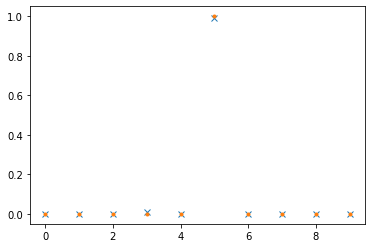

In [22]:
from matplotlib.pyplot import *
Yhattrain=model1.predict(Xtrain)
Yhattest=model1.predict(Xtest)
plot(Yhattrain[0],'x')
plot(Ytrain[0],'.')

## ***모형을 평가하는 방법***

In [23]:
trainloss,trainacc = model1.evaluate(Xtrain,Ytrain)
testloss,testacc = model1.evaluate(Xtest,Ytest)
print(trainloss,trainacc)
print(testloss,testacc)

313/313 [==============================] - 0s 1ms/step - loss: 0.2500 - accuracy: 0.9686
0.2280748188495636 0.9768333435058594
0.24998071789741516 0.9685999751091003
